In [2]:
import os
import cv2
import torch
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import torch.nn as nn
import seaborn as sns
from PIL import Image
from scipy import stats
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import torchvision.models as models
from scipy.stats import randint, uniform
import torchvision.transforms as transforms
from skimage.measure import regionprops, label
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFECV


# Feature Extraction

This section extracts handcrafted features from dermoscopic skin images to help classify lesions as benign or malignant.

The extracted features include:

- **Color Features:** statistical measurements from HSV and LAB color spaces such as mean, standard deviation, skewness, and kurtosis.

- **Texture Features:** GLCM-based texture descriptors including contrast, homogeneity, energy, correlation, and ASM.

- **Shape Features:** morphological descriptors based on the ABCD rule such as asymmetry, compactness, border irregularity, solidity, and lesion area.

- **Clinical Features:** patient metadata including age, sex, and anatomical site.

Finally, all extracted features are combined into a single feature vector for machine learning classification.

In [3]:


# ─────────────────────────────────────────────
# 1. COLOR FEATURES
# ─────────────────────────────────────────────
def extract_color_features(image, mask):
    """
    Extract color statistics from the lesion region (RGB, HSV, LAB).
    Captures mean, std, skewness, kurtosis per channel.
    """
    features = {}
    binary_mask = mask > 0

    if binary_mask.sum() == 0:
        # Return zeros if mask is empty
        for space in ['rgb', 'hsv', 'lab']:
            n = 3 if space != 'lab' else 3
            for ch in range(n):
                for stat in ['mean', 'std', 'skew', 'kurt']:
                    features[f'{space}_ch{ch}_{stat}'] = 0.0
        return features

    # ── HSV ──
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    for ch_idx, ch_name in enumerate(['h', 's', 'v']):
        channel = hsv[:, :, ch_idx][binary_mask].astype(np.float32)
        features[f'hsv_{ch_name}_mean'] = float(np.mean(channel))
        features[f'hsv_{ch_name}_std']  = float(np.std(channel))
        features[f'hsv_{ch_name}_skew'] = float(stats.skew(channel))
        features[f'hsv_{ch_name}_kurt'] = float(stats.kurtosis(channel))

    # ── LAB ──
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    for ch_idx, ch_name in enumerate(['l', 'a', 'b_ch']):
        channel = lab[:, :, ch_idx][binary_mask].astype(np.float32)
        features[f'lab_{ch_name}_mean'] = float(np.mean(channel))
        features[f'lab_{ch_name}_std']  = float(np.std(channel))
        features[f'lab_{ch_name}_skew'] = float(stats.skew(channel))
        features[f'lab_{ch_name}_kurt'] = float(stats.kurtosis(channel))

    return features


# ─────────────────────────────────────────────
# 2. TEXTURE FEATURES
# ─────────────────────────────────────────────

def extract_texture_features(image, mask):
    features = {}
    binary_mask = (mask > 0).astype(np.uint8)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # ── GLCM ──
    rows, cols = np.where(binary_mask > 0)
    if len(rows) == 0:
        for prop in ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']:
            for d in [1, 3]:
                features[f'glcm_{prop}_d{d}'] = 0.0
    else:
        r_min, r_max = rows.min(), rows.max()
        c_min, c_max = cols.min(), cols.max()
        roi = gray[r_min:r_max+1, c_min:c_max+1]
        
        for d in [1, 3]:
            glcm = graycomatrix(roi, distances=[d],
                                angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                                levels=256, symmetric=True, normed=True)
            for prop in ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']:
                features[f'glcm_{prop}_d{d}'] = float(graycoprops(glcm, prop).mean())

    return features


# ─────────────────────────────────────────────
# 3. SHAPE / MORPHOLOGICAL FEATURES (ABCD Rule)
# ─────────────────────────────────────────────
def extract_shape_features(mask):
    """
    Captures the clinical ABCD dermoscopy rule:
      A — Asymmetry  (asymmetry index, compactness)
      B — Border     (irregularity index, fractal-like perimeter)
      C — (color handled separately)
      D — Diameter   (relative lesion area)
    Also: solidity, extent, major/minor axis ratio.
    """
    features = {}
    binary_mask = (mask > 0).astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours:
        for k in ['area', 'perimeter', 'compactness', 'asymmetry_index',
                  'border_irregularity', 'solidity', 'extent',
                  'major_minor_ratio', 'equiv_diameter', 'convex_hull_ratio']:
            features[k] = 0.0
        return features

    # Largest contour = lesion boundary
    cnt = max(contours, key=cv2.contourArea)
    area      = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    h, w      = mask.shape

    features['area']           = float(area)
    features['perimeter']      = float(perimeter)
    features['relative_area']  = float(area / (h * w))  # normalized

    # Compactness = 4π·A / P²  (circle = 1, irregular shape < 1)
    features['compactness'] = float((4 * np.pi * area) / (perimeter ** 2 + 1e-6))

    # Border Irregularity Index = P / (2·sqrt(π·A))
    features['border_irregularity'] = float(perimeter / (2 * np.sqrt(np.pi * area + 1e-6)))

    # Convex hull ratio (solidity) — measures how "convex" the lesion is
    hull        = cv2.convexHull(cnt)
    hull_area   = cv2.contourArea(hull)
    features['solidity']           = float(area / (hull_area + 1e-6))
    features['convex_hull_ratio']  = float(hull_area / (area + 1e-6))

    # Fit ellipse for axis ratio (elongation)
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (MA, ma), angle = ellipse
        features['major_minor_ratio'] = float(max(MA, ma) / (min(MA, ma) + 1e-6))
        features['ellipse_angle']     = float(angle)
    else:
        features['major_minor_ratio'] = 1.0
        features['ellipse_angle']     = 0.0

    # Equivalent diameter
    features['equiv_diameter'] = float(np.sqrt(4 * area / np.pi))

    # ── Asymmetry Index ──
    # Compare the lesion mask against its horizontally and vertically flipped versions
    mask_bool = binary_mask.astype(bool)
    flip_h    = np.fliplr(mask_bool)
    flip_v    = np.flipud(mask_bool)

    asym_h = np.logical_xor(mask_bool, flip_h).sum() / (mask_bool.sum() + 1e-6)
    asym_v = np.logical_xor(mask_bool, flip_v).sum() / (mask_bool.sum() + 1e-6)
    features['asymmetry_h']     = float(asym_h)
    features['asymmetry_v']     = float(asym_v)
    features['asymmetry_index'] = float((asym_h + asym_v) / 2)

    # Bounding box extent (lesion area / bounding box area)
    x, y, bw, bh = cv2.boundingRect(cnt)
    features['extent'] = float(area / (bw * bh + 1e-6))

    return features


# ─────────────────────────────────────────────
# 4. TABULAR (CLINICAL) FEATURES
# ─────────────────────────────────────────────
def extract_tabular_features(tabular_row):
    """
    Encode age, sex, anatomical site.
    tabular_row = [age, sex (0/1), anatom_site (0–5)]
    """
    age, sex, site = tabular_row
    features = {
        'age':      float(age),
        'sex':      float(sex),
        'anatom_site': float(site),
        # Clinical risk: melanoma risk rises sharply after 50
        'age_over_50':  float(age > 50),
        'age_over_65':  float(age > 65),
    }
    # One-hot encode anatomical site (6 possible sites)
    for s in range(6):
        features[f'site_{s}'] = float(site == s)
    return features


# ─────────────────────────────────────────────
# 5. MASTER EXTRACTION LOOP
# ─────────────────────────────────────────────
def extract_all_features(images, tabular, labels=None):

    all_rows = []

    for i in range(len(images)):
        img = images[i]
        tab = tabular[i]

        # Resize for speed
        # img = cv2.resize(img, (128, 128))

        # Create mask directly from image
        # assumes background is black / near black
        mask = np.any(img > 0, axis=-1).astype(np.uint8) * 255

        row = {}

        row.update(extract_color_features(img, mask))
        row.update(extract_texture_features(img, mask))
        row.update(extract_shape_features(mask))
        row.update(extract_tabular_features(tab))

        if labels is not None:
            row["label"] = int(labels[i])

        all_rows.append(row)

        if (i + 1) % 100 == 0:
            print(f"Processed {i+1}/{len(images)}")

    return pd.DataFrame(all_rows)


In [4]:
# import os
# print(os.listdir('/kaggle/input'))
# print(os.listdir('/kaggle/input/datasets/shahdaymanrizk'))

In [5]:
# ── Feature extraction on each split ──
DATA_DIR = "D:/ML_notebook/processed_data_segBig_npy"


train_masked_images = np.load(os.path.join(DATA_DIR, "train/train_images.npy"))
val_masked_images = np.load(os.path.join(DATA_DIR, "val/val_images.npy"))
test_masked_images = np.load(os.path.join(DATA_DIR, "test/test_images.npy"))

X_tab_train = np.load(os.path.join(DATA_DIR, "train/train_tabular.npy"))
X_tab_val = np.load(os.path.join(DATA_DIR, "val/val_tabular.npy"))
X_tab_test = np.load(os.path.join(DATA_DIR, "test/test_tabular.npy"))

y_train = np.load(os.path.join(DATA_DIR, "train/train_labels.npy"))
y_val = np.load(os.path.join(DATA_DIR, "val/val_labels.npy"))
y_test = np.load(os.path.join(DATA_DIR, "test/test_labels.npy"))


print("Extracting TRAIN features...")
train_features_df = extract_all_features(train_masked_images, X_tab_train, y_train)

print("\nExtracting VAL features...")
val_features_df = extract_all_features(val_masked_images, X_tab_val, y_val)

print("\nExtracting TEST features...")
test_features_df = extract_all_features(test_masked_images, X_tab_test, y_test)

train_features_df.to_csv("train_features.csv", index=False)
val_features_df.to_csv("val_features.csv", index=False)
test_features_df.to_csv("test_features.csv", index=False)
# submission_features_df.to_csv("submission_features.csv", index=False)

print(f"\nShapes:")
print(f"  train_features_df   : {train_features_df.shape}")
print(f"  val_features_df     : {val_features_df.shape}")
print(f"  test_features_df    : {test_features_df.shape}")
# print(f"  submission_features_df: {submission_features_df.shape}")

Extracting TRAIN features...
Processed 100/2119
Processed 200/2119
Processed 300/2119
Processed 400/2119
Processed 500/2119
Processed 600/2119
Processed 700/2119
Processed 800/2119
Processed 900/2119
Processed 1000/2119
Processed 1100/2119
Processed 1200/2119
Processed 1300/2119
Processed 1400/2119
Processed 1500/2119
Processed 1600/2119
Processed 1700/2119
Processed 1800/2119
Processed 1900/2119
Processed 2000/2119
Processed 2100/2119

Extracting VAL features...
Processed 100/302
Processed 200/302
Processed 300/302

Extracting TEST features...
Processed 100/303
Processed 200/303
Processed 300/303

Shapes:
  train_features_df   : (2119, 62)
  val_features_df     : (302, 62)
  test_features_df    : (303, 62)


# Feature Selection

This step prepares the feature matrix for training by separating features and labels, handling missing values, and analyzing the extracted feature groups:
- Color features
- Texture features
- Shape features
- Clinical features

In [6]:
#  3: Feature selection 
def prepare_X_y(df, label_col='label'):
    y = df[label_col].values.astype(int)
    X = df.drop(columns=[label_col]).copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    return X, y

# Fit ONLY on train split
X_tr, y_tr = prepare_X_y(train_features_df)
print(f"Feature matrix: {X_tr.shape[0]} samples × {X_tr.shape[1]} features")
print(f"  Color   : {len([c for c in X_tr.columns if c.startswith(('rgb','hsv','lab','color'))])}")
print(f"  Texture : {len([c for c in X_tr.columns if c.startswith(('glcm','lbp'))])}")
print(f"  Shape   : {len([c for c in X_tr.columns if any(s in c for s in ['area','perim','asym','border','solid','compact','extent','equiv','ellipse','convex','major'])])}")
print(f"  Tabular : {len([c for c in X_tr.columns if c.startswith(('age','sex','anatom','site'))])}")

Feature matrix: 2119 samples × 61 features
  Color   : 24
  Texture : 12
  Shape   : 14
  Tabular : 11


# Hybrid Feature Selection

This step removes highly correlated features, scales the data, and selects the most important features using a hybrid approach combining:
- ANOVA
- Mutual Information
- XGBoost feature importance

The top-ranked features(25 Feature) are then used to create the final training and testing datasets.

In [7]:

# ─────────────────────────────────────────────
# PREPARE
# ─────────────────────────────────────────────
def prepare_X_y(df, label_col='label'):
    y = df[label_col].values.astype(int)
    X = df.drop(columns=[label_col]).copy()

    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    return X, y


# ─────────────────────────────────────────────
# REMOVE CORRELATED FEATURES
# ─────────────────────────────────────────────
def remove_correlated_features(X, threshold=0.85):

    corr = X.corr().abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    to_drop = [
        col for col in upper.columns
        if any(upper[col] > threshold)
    ]

    X_clean = X.drop(columns=to_drop)

    print(f"Removed correlated features: {len(to_drop)}")
    print(f"Remaining features: {X_clean.shape[1]}")

    return X_clean


# ─────────────────────────────────────────────
# HYBRID FEATURE SELECTION (IMPROVED)
# ─────────────────────────────────────────────
def select_features(X, y, feat_names, top_k=25):

    # =========================
    # ANOVA
    # =========================
    f_vals, _ = f_classif(X, y)
    f_rank = pd.Series(f_vals, index=feat_names).rank(pct=True)

    # =========================
    # Mutual Information
    # =========================
    mi_vals = mutual_info_classif(
        X, y,
        random_state=42
    )
    mi_rank = pd.Series(mi_vals, index=feat_names).rank(pct=True)

    # =========================
    # XGBoost importance (IMPROVED)
    # =========================
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        eval_metric='auc',
        random_state=42,
        scale_pos_weight=scale_pos_weight
    )

    model.fit(X, y)

    xgb_rank = pd.Series(
        model.feature_importances_,
        index=feat_names
    ).rank(pct=True)

    # =========================
    # FINAL WEIGHTED SCORE
    # =========================
    score = (
        0.3 * f_rank +
        0.4 * mi_rank +
        0.3 * xgb_rank
    ).sort_values(ascending=False)

    selected = score.head(top_k).index.tolist()

    return selected, score


# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────
print("=" * 50)
print("FEATURE SELECTION (IMPROVED)")
print("=" * 50)

# 1. load data
X, y = prepare_X_y(train_features_df)

# 2. make binary (IMPORTANT FIX)
# malignant = [1,3,4] → adjust if needed
y = np.isin(y, [0,1,2]).astype(int)

print("Binary distribution:", np.bincount(y))

# 3. remove correlated features
X = remove_correlated_features(X, threshold=0.85)

# 4. scale (IMPORTANT FIX: fit only on train)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. feature selection
selected_features, scores = select_features(
    X_scaled,
    y,
    X.columns.tolist(),
    top_k=25
)

print("\nSelected features:")
print(selected_features)

# 6. final datasets
X_train_selected = train_features_df[selected_features + ['label']]
X_test_selected  = test_features_df[selected_features + ['label']]

print("\nTrain shape:", X_train_selected.shape)
print("Test shape :", X_test_selected.shape)

FEATURE SELECTION (IMPROVED)
Binary distribution: [1292  827]
Removed correlated features: 19
Remaining features: 42

Selected features:
['age', 'lab_a_mean', 'lab_b_ch_skew', 'hsv_s_skew', 'lab_a_std', 'area', 'hsv_v_std', 'hsv_s_mean', 'compactness', 'lab_b_ch_std', 'age_over_50', 'hsv_h_std', 'hsv_v_mean', 'hsv_s_kurt', 'hsv_v_skew', 'hsv_h_skew', 'hsv_h_mean', 'asymmetry_h', 'lab_b_ch_mean', 'solidity', 'hsv_v_kurt', 'lab_a_kurt', 'hsv_s_std', 'lab_a_skew', 'age_over_65']

Train shape: (2119, 26)
Test shape : (303, 26)


In [8]:
print(f"\n✓ Final selected features: {len(selected_features)}")


✓ Final selected features: 25


# Data Scaling

This step rebuilds the final scaled datasets using the selected features.

The scaler is fitted on the training data and then applied to:
- validation data
- test data

Finally, the corresponding label arrays are prepared for model training and evaluation.

In [9]:
scaler_final   = StandardScaler()

X_train_scaled = scaler_final.fit_transform(
    train_features_df[selected_features].fillna(0))
X_val_scaled   = scaler_final.transform(
    val_features_df[selected_features].fillna(0))
X_test_scaled  = scaler_final.transform(
    test_features_df[selected_features].fillna(0))
# X_sub_scaled   = scaler_final.transform(
#     submission_features_df[selected_features].fillna(0))

y_train_fs = train_features_df['label'].values.astype(int)
y_val_fs   = val_features_df['label'].values.astype(int)
y_test_fs  = test_features_df['label'].values.astype(int)

print(f"✓ X_train_scaled : {X_train_scaled.shape}")
print(f"✓ X_val_scaled   : {X_val_scaled.shape}")
print(f"✓ X_test_scaled  : {X_test_scaled.shape}")
print(f"✓ y_train_fs     : {y_train_fs.shape}")
print(f"✓ y_val_fs       : {y_val_fs.shape}")
print(f"✓ y_test_fs      : {y_test_fs.shape}")

✓ X_train_scaled : (2119, 25)
✓ X_val_scaled   : (302, 25)
✓ X_test_scaled  : (303, 25)
✓ y_train_fs     : (2119,)
✓ y_val_fs       : (302,)
✓ y_test_fs      : (303,)


In [10]:
# print(train_features_df["label"].head(10))
# # print(train_features_df["label"].unique())

# Model Training and Evaluation

This section converts the dataset into binary labels (malignant vs benign) and trains an XGBoost classifier.

The pipeline includes:
- handling class imbalance using `scale_pos_weight`,
- optional hyperparameter tuning with `RandomizedSearchCV`,
- model training with validation monitoring,
- threshold optimization using Youden’s index,
- and final evaluation using AUC-ROC and F1-score on:
  - training,
  - validation,
  - and test sets.

In [11]:

def make_binary_labels(y):
    malignant = [0,1,2]
    return np.isin(y, malignant).astype(int)


y_train = make_binary_labels(train_features_df['label'].values)
y_val   = make_binary_labels(val_features_df['label'].values)
y_test  = make_binary_labels(test_features_df['label'].values)

print("Train distribution:", np.bincount(y_train))
print("Val distribution:", np.bincount(y_val))
print("Test distribution:", np.bincount(y_test))

Train distribution: [1292  827]
Val distribution: [181 121]
Test distribution: [181 122]


In [15]:

# =========================================================
# MODEL 
# =========================================================
def get_model(scale_pos_weight):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        
        max_depth=3,               
        min_child_weight=25,       
        learning_rate=0.035,
        n_estimators=500,
        
        subsample=0.6,
        colsample_bytree=0.5,
        
        reg_alpha=2.0,
        reg_lambda=6.0,
        gamma=4.0,
        
        scale_pos_weight=scale_pos_weight
    )



# =========================================================
# THRESHOLD + EVALUATION
# =========================================================
def find_best_threshold(model, X_val, y_val):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    youden = tpr + (1 - fpr) - 1
    best_idx = np.argmax(youden)
    best_threshold = thresholds[best_idx]
    print("\nBest threshold:", round(best_threshold, 4))
    return best_threshold


def evaluate(model, X, y, threshold, name="SET"):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    auc = roc_auc_score(y, y_prob)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{name:12} →  AUC: {auc:.4f} | F1: {f1:.4f}")
    return auc, f1


# =========================================================
# FULL PIPELINE 
# =========================================================
def run_pipeline(X_train, y_train, X_val, y_val, X_test, y_test):
    print("=== Training XGBoost ===\n")
    

    # 2. Train Model
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = get_model(scale_pos_weight)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50          # بيطبع كل 50 iteration
    )
    
    # 3. Threshold Tuning
    best_threshold = find_best_threshold(model, X_val, y_val)
    
    # 4. Evaluation
    evaluate(model, X_train, y_train, best_threshold, name="TRAIN")
    evaluate(model, X_val,   y_val,   best_threshold, name="VALIDATION")
    evaluate(model, X_test,  y_test,  best_threshold, name="TEST")
    
    return model, best_threshold


# ====================== RUN ======================
model, threshold = run_pipeline(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled, y_test
)

=== Training XGBoost ===

[0]	validation_0-auc:0.74750


[50]	validation_0-auc:0.79823
[100]	validation_0-auc:0.79987
[150]	validation_0-auc:0.80307
[200]	validation_0-auc:0.80289
[250]	validation_0-auc:0.80558
[300]	validation_0-auc:0.80558
[350]	validation_0-auc:0.80599
[400]	validation_0-auc:0.80604
[450]	validation_0-auc:0.80544
[499]	validation_0-auc:0.80567

Best threshold: 0.4348

TRAIN        →  AUC: 0.9286 | F1: 0.8145

VALIDATION   →  AUC: 0.8057 | F1: 0.7128

TEST         →  AUC: 0.8579 | F1: 0.7491


In [16]:
from sklearn.metrics import f1_score


y_train_pred_tuned = (model.predict_proba(X_train_scaled)[:, 1] >= threshold).astype(int)
f1_train_corrected = f1_score(y_train, y_train_pred_tuned)

y_val_pred_tuned = (model.predict_proba(X_val_scaled)[:, 1] >= threshold).astype(int)
f1_val_corrected = f1_score(y_val, y_val_pred_tuned)

y_test_pred_tuned = (model.predict_proba(X_test_scaled)[:, 1] >= threshold).astype(int)
f1_test_corrected = f1_score(y_test, y_test_pred_tuned)

print(f"Corrected Train F1: {f1_train_corrected:.4f}")
print(f"Corrected Val F1:   {f1_val_corrected:.4f}")
print(f"Corrected Test F1:  {f1_test_corrected:.4f}")

Corrected Train F1: 0.8145
Corrected Val F1:   0.7128
Corrected Test F1:  0.7491


## Performance Analysis & Visualization

This section evaluates the trained XGBoost model using multiple visualization techniques.  
It generates training/validation learning curves, confusion matrices, ROC curves, feature importance plots, and a final performance dashboard to assess classification quality and model generalization.

  PERFORMANCE ANALYSIS — Skin Lesion Classification

[1/4] Plotting Training vs. Validation Curves …
  Saved → performance_figures\01_training_curves.png


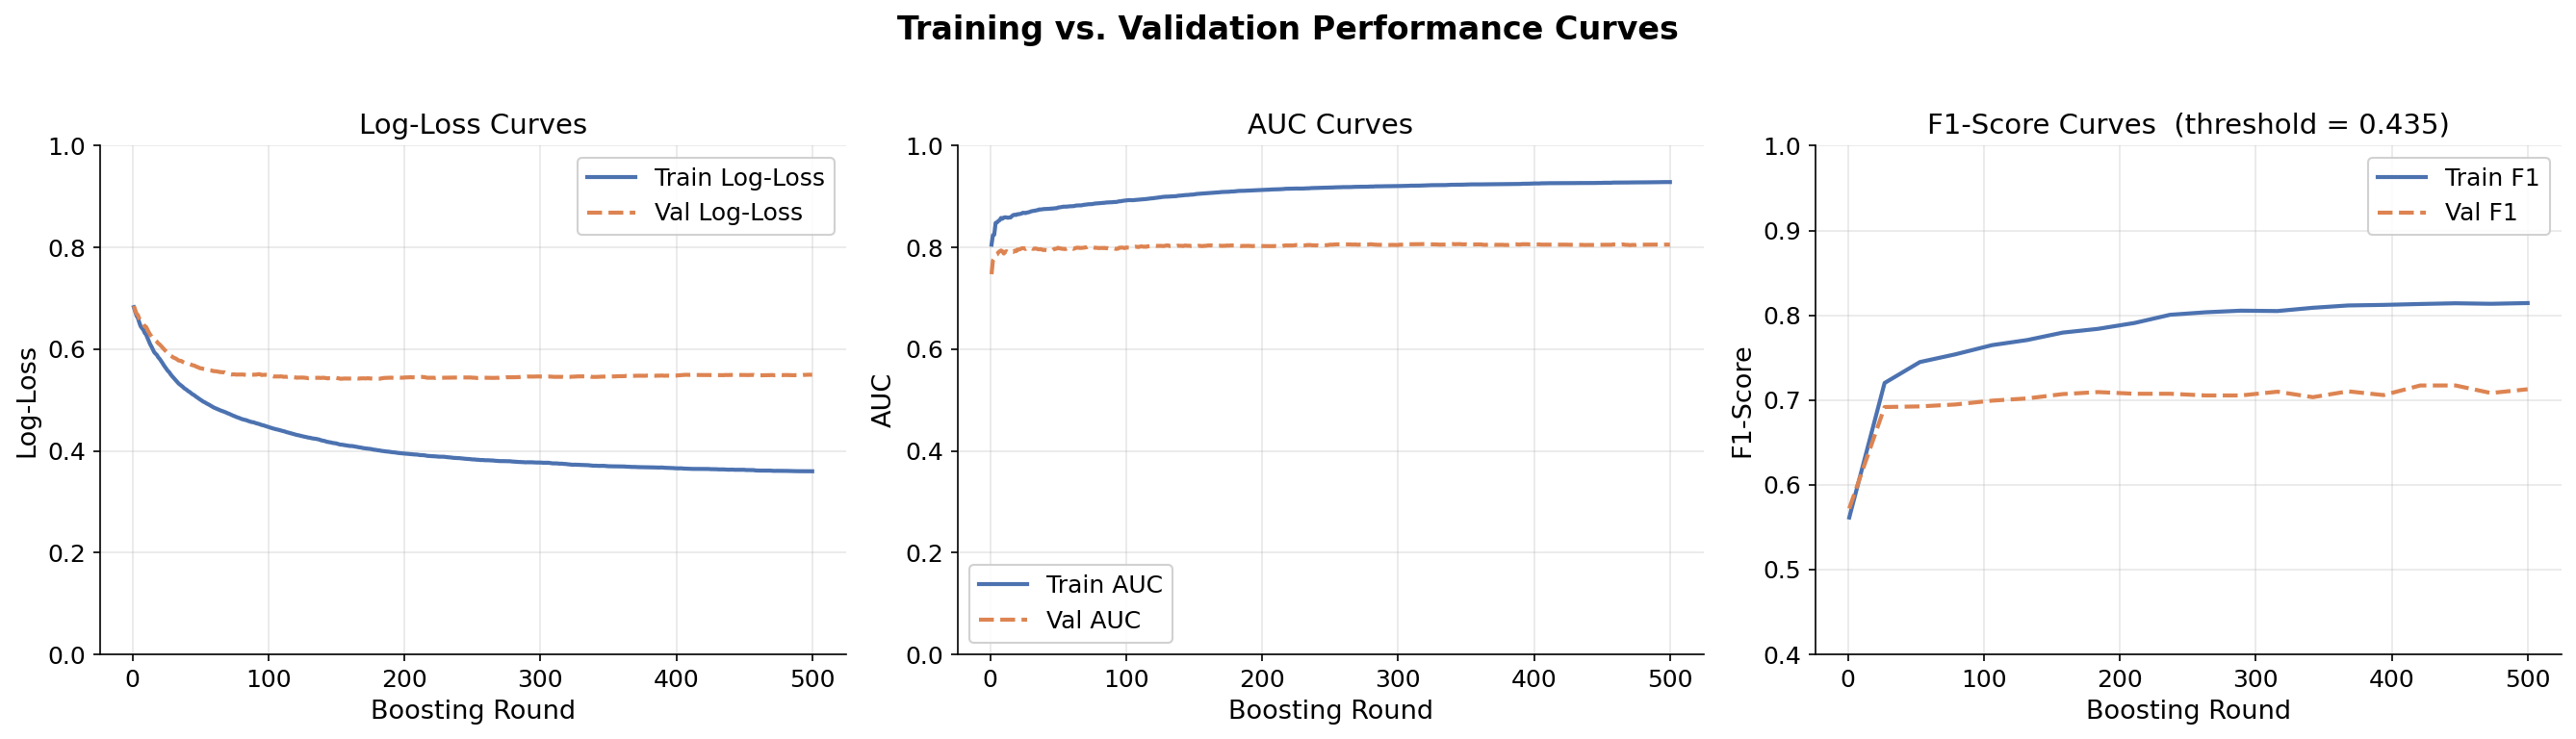


[2/4] Plotting Confusion Matrices …
  Saved → performance_figures\02_confusion_matrix.png


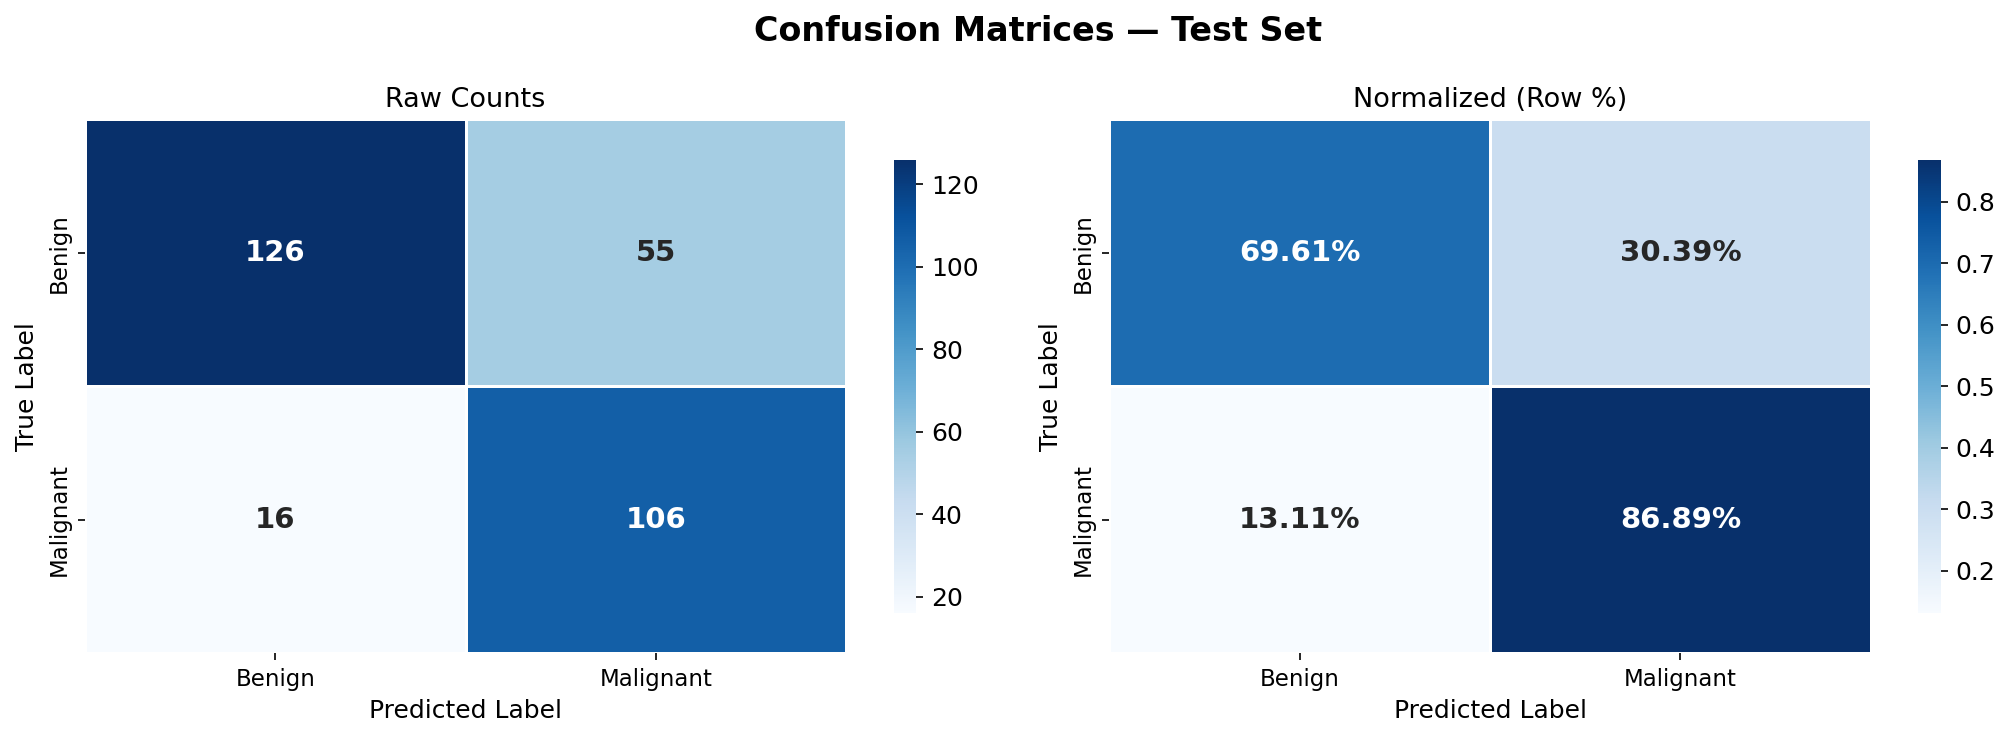


Classification Report (Test Set):
              precision    recall  f1-score   support

      Benign       0.89      0.70      0.78       181
   Malignant       0.66      0.87      0.75       122

    accuracy                           0.77       303
   macro avg       0.77      0.78      0.76       303
weighted avg       0.80      0.77      0.77       303


[3/4] Plotting Feature Importance …
  Saved → performance_figures\03_feature_importance.png


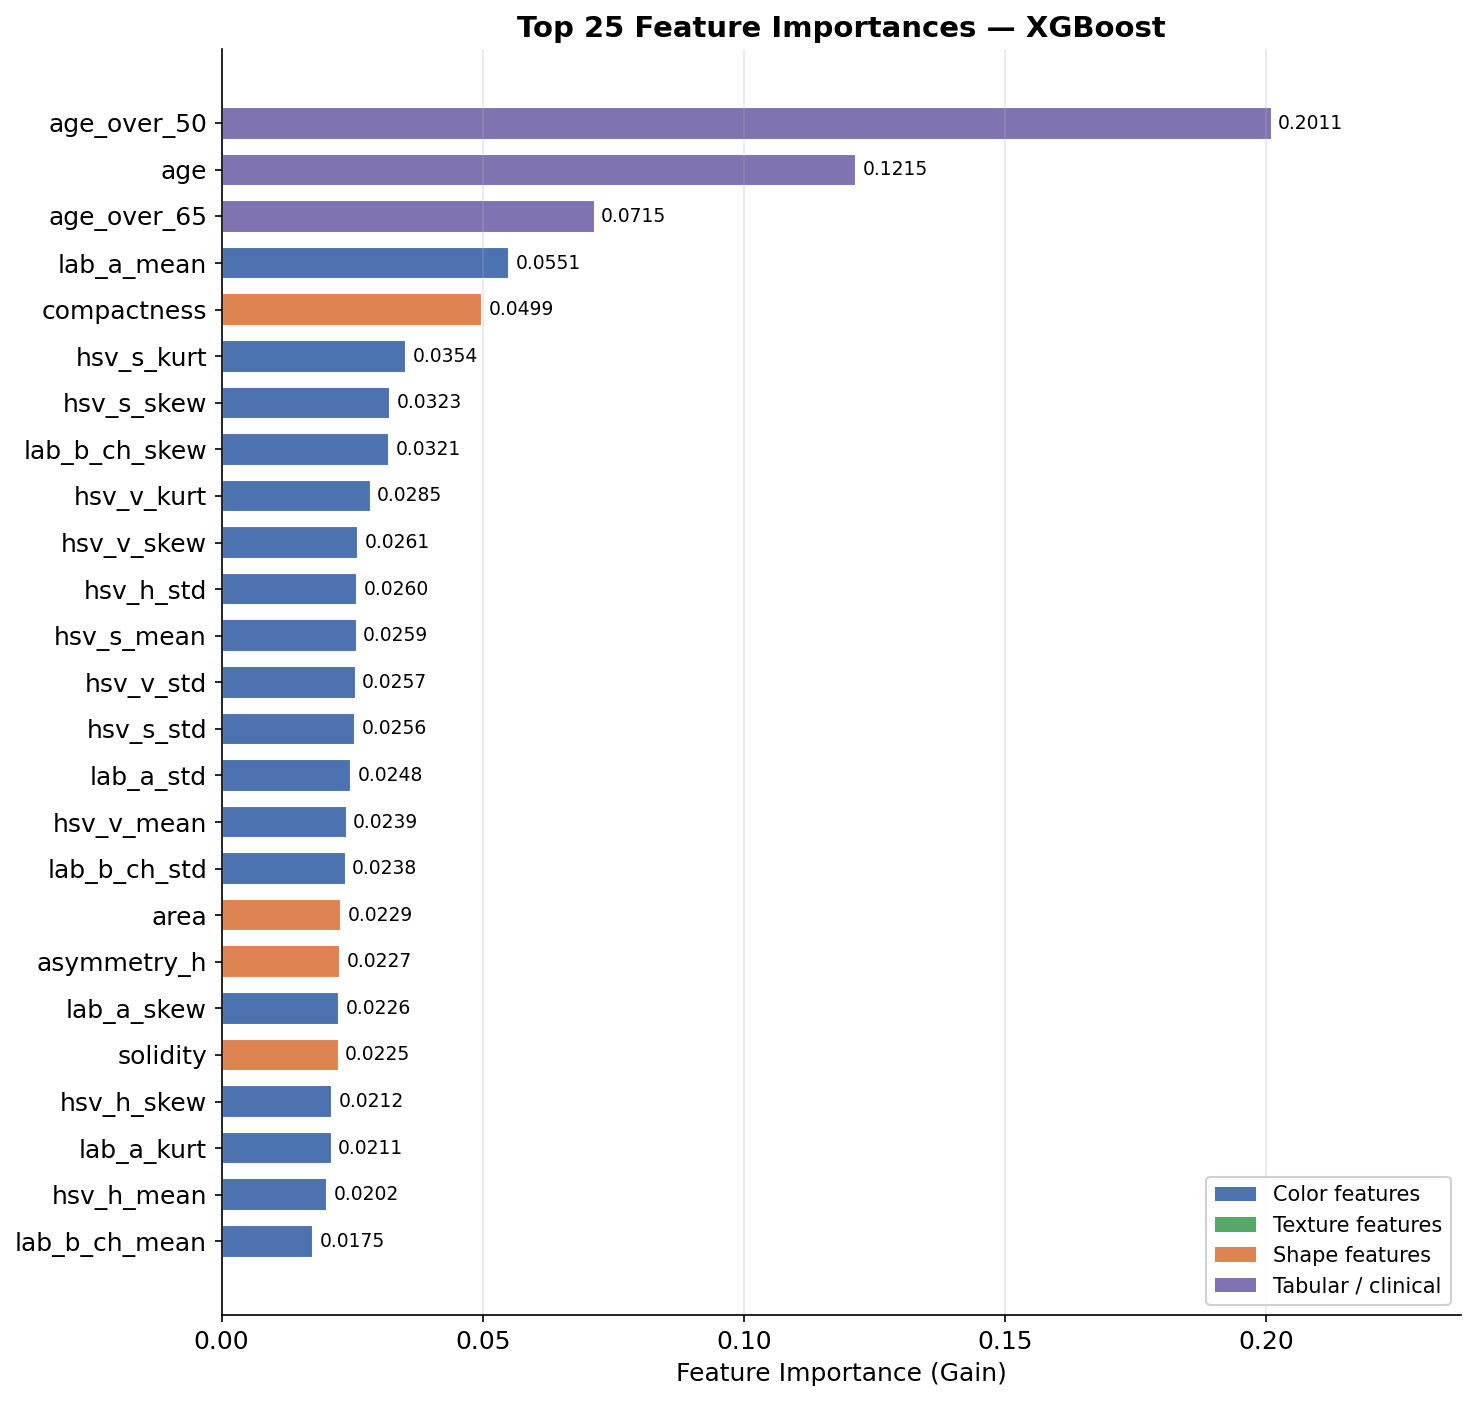


[4/4] Plotting ROC Curves …
  Saved → performance_figures\04_roc_curves.png


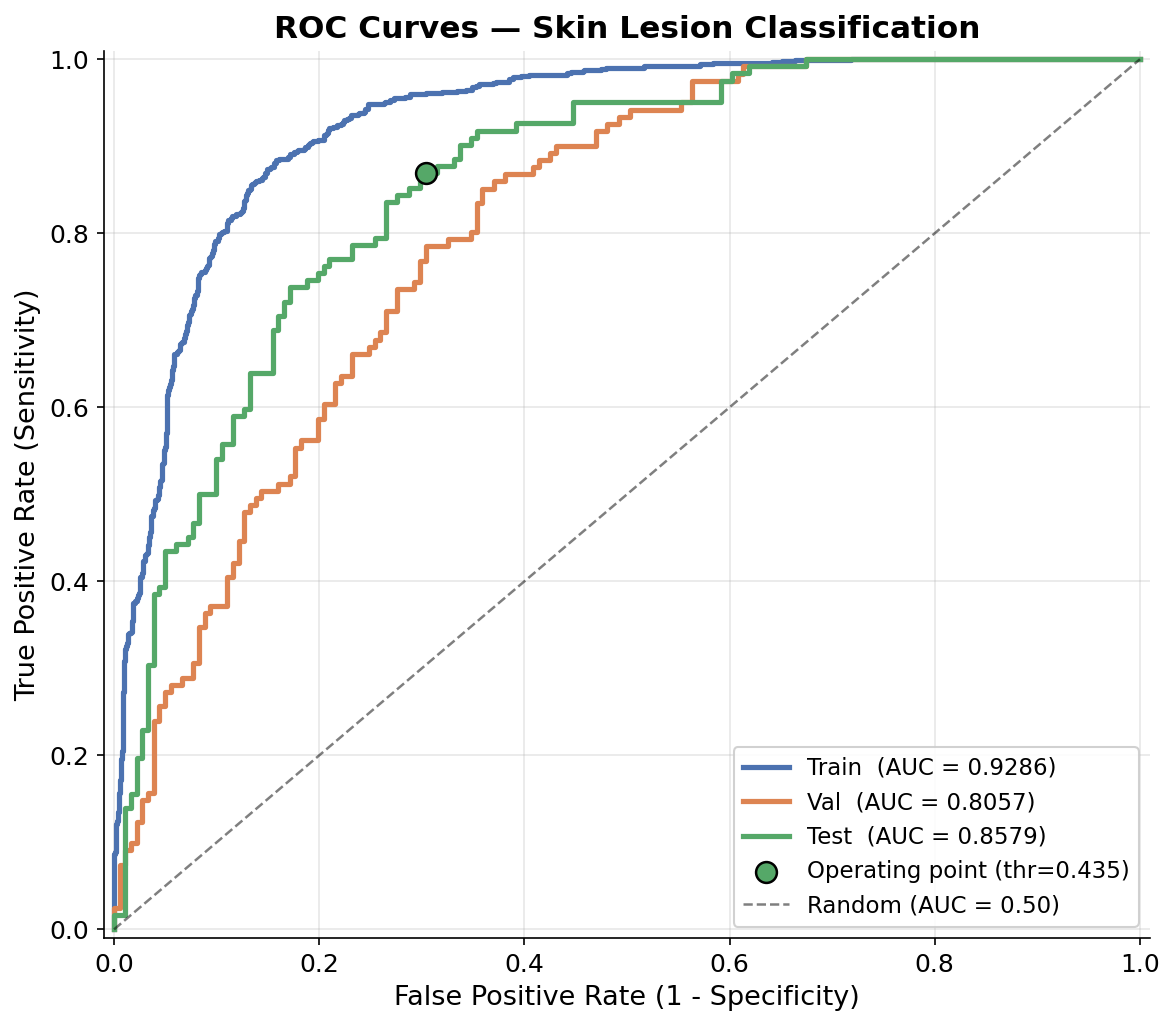


[BONUS] Plotting Summary Dashboard …
  Saved → performance_figures\05_summary_dashboard.png


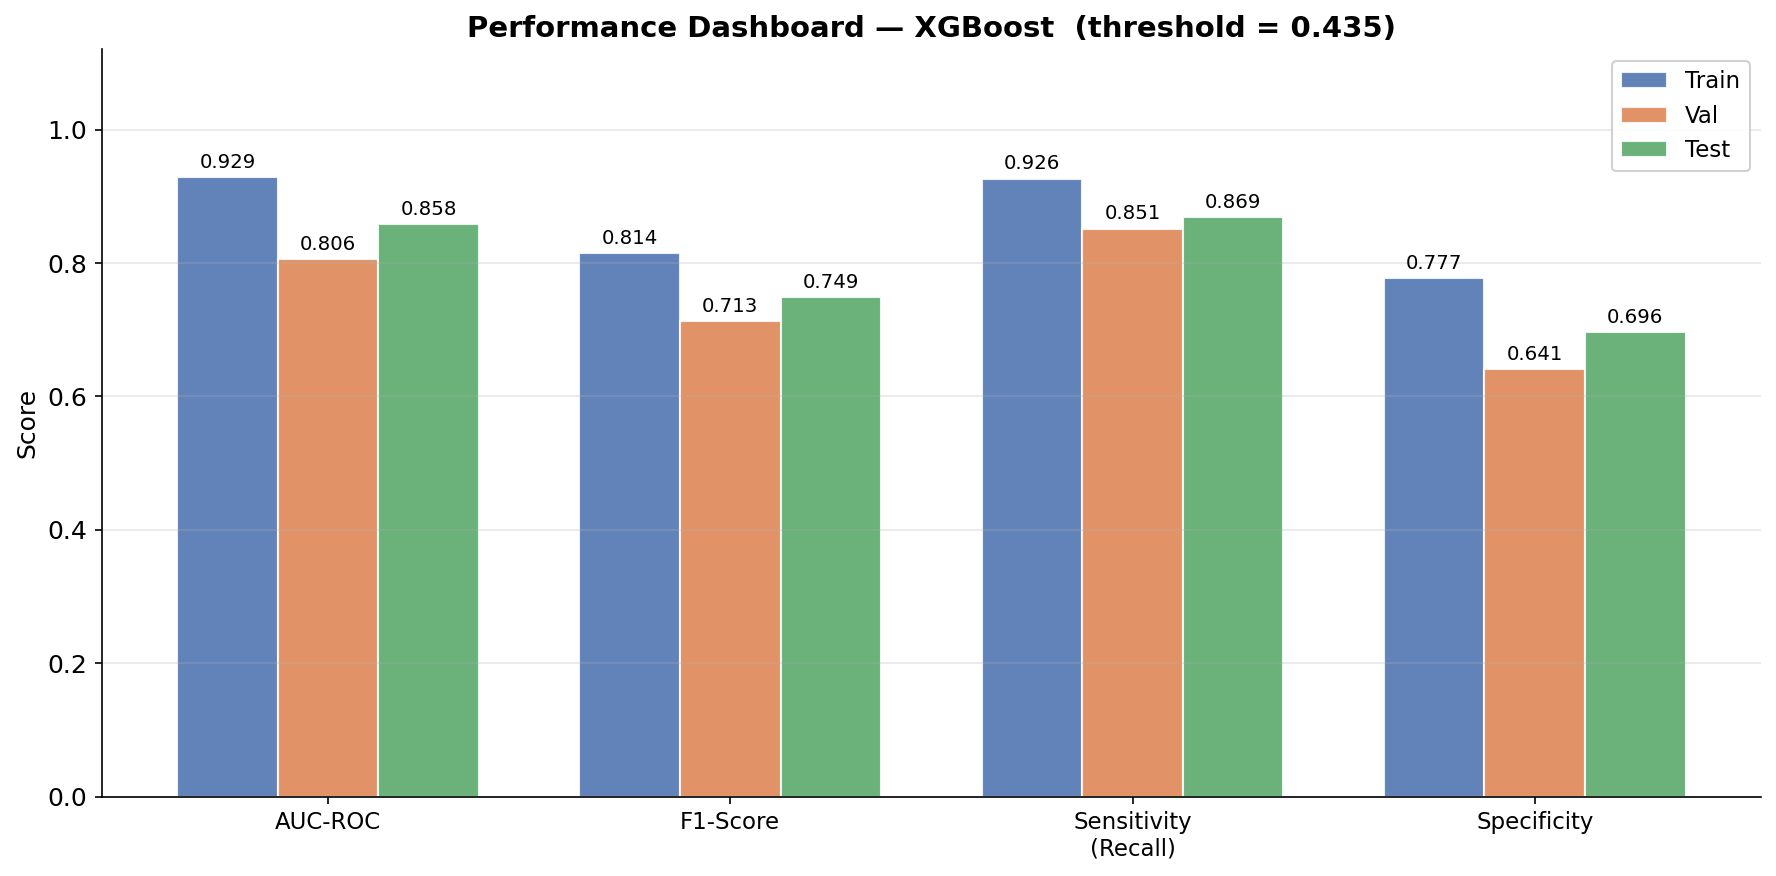


  All figures saved to: ./performance_figures/


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION: COMPLETE PERFORMANCE ANALYSIS
# Skin Lesion Classification — Publication-Quality Visualizations
# ═══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import label_binarize

# ── Output directory ──
FIGURES_DIR = "performance_figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Global aesthetics ──
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

# ── Color palette ──
PALETTE = {
    "train":   "#4C72B0",
    "val":     "#DD8452",
    "test":    "#55A868",
    "fp":      "#C44E52",
    "neutral": "#8172B2",
}

CLASS_NAMES = ["Benign", "Malignant"]

# ─────────────────────────────────────────────
# HELPER: safe save
# ─────────────────────────────────────────────
def save_fig(fig, name, subdir=FIGURES_DIR):
    path = os.path.join(subdir, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")
    return path


# ═══════════════════════════════════════════════════════════════════════════════
# 1. TRAINING vs. VALIDATION CURVES
# ═══════════════════════════════════════════════════════════════════════════════

def plot_training_curves(model, X_train, y_train, X_val, y_val, n_checkpoints=20):
    """
    Re-train the XGBoost model with staged evaluation to collect
    per-round metrics, then plot loss and F1 curves.
    """
    import xgboost as xgb
    from sklearn.metrics import log_loss

    print("\n[1/4] Plotting Training vs. Validation Curves …")

    # ── Staged evaluation ──
    eval_results = {}
    # Build params cleanly — exclude keys that we override to avoid duplicates
    base_params = {k: v for k, v in model.get_params().items()
                   if k not in ("n_estimators", "eval_metric")}
    model_cv = xgb.XGBClassifier(
        **base_params,
        n_estimators=model.n_estimators,
        eval_metric=["logloss", "auc"],
    )
    model_cv.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    results = model_cv.evals_result()
    train_loss = results["validation_0"]["logloss"]
    val_loss   = results["validation_1"]["logloss"]
    train_auc  = results["validation_0"]["auc"]
    val_auc    = results["validation_1"]["auc"]
    epochs     = np.arange(1, len(train_loss) + 1)

    # ── F1 curve at sampled checkpoints ──
    n_trees       = model.n_estimators
    checkpoint_iters = np.linspace(1, n_trees, n_checkpoints, dtype=int)
    train_f1s, val_f1s = [], []
    thr = threshold  # Youden threshold from pipeline

    for n in checkpoint_iters:
        p_tr = model_cv.predict_proba(X_train, iteration_range=(0, n))[:, 1]
        p_vl = model_cv.predict_proba(X_val,   iteration_range=(0, n))[:, 1]
        train_f1s.append(f1_score(y_train, (p_tr >= thr).astype(int), zero_division=0))
        val_f1s.append(f1_score(y_val,   (p_vl >= thr).astype(int), zero_division=0))

    # ── Figure ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training vs. Validation Performance Curves", fontsize=16, fontweight="bold", y=1.02)

    # Loss
    ax = axes[0]
    ax.plot(epochs, train_loss, color=PALETTE["train"], lw=2, label="Train Log-Loss")
    ax.plot(epochs, val_loss,   color=PALETTE["val"],   lw=2, label="Val Log-Loss",   ls="--")
    ax.set_xlabel("Boosting Round"); ax.set_ylabel("Log-Loss")
    ax.set_title("Log-Loss Curves"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

    # AUC
    ax = axes[1]
    ax.plot(epochs, train_auc, color=PALETTE["train"], lw=2, label="Train AUC")
    ax.plot(epochs, val_auc,   color=PALETTE["val"],   lw=2, label="Val AUC",   ls="--")
    ax.set_xlabel("Boosting Round"); ax.set_ylabel("AUC")
    ax.set_title("AUC Curves"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

    # F1
    ax = axes[2]
    ax.plot(checkpoint_iters, train_f1s, color=PALETTE["train"], lw=2, label="Train F1")
    ax.plot(checkpoint_iters, val_f1s,   color=PALETTE["val"],   lw=2, label="Val F1", ls="--")
    ax.set_xlabel("Boosting Round"); ax.set_ylabel("F1-Score")
    ax.set_title(f"F1-Score Curves  (threshold = {thr:.3f})"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(0.4, 1)

    plt.tight_layout()
    save_fig(fig, "01_training_curves.png")
    plt.show()
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# 2. CONFUSION MATRIX (raw + normalized)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrices(y_true, y_pred, class_names=CLASS_NAMES):
    print("\n[2/4] Plotting Confusion Matrices …")

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")

    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ["Raw Counts", "Normalized (Row %)"],
        ["d", ".2%"]
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"},
            ax=ax, cbar_kws={"shrink": 0.85}
        )
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Predicted Label", fontsize=12)
        ax.set_ylabel("True Label", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)

    plt.tight_layout()
    save_fig(fig, "02_confusion_matrix.png")
    plt.show()

    # Print classification report
    print("\nClassification Report (Test Set):")
    print(classification_report(y_true, y_pred, target_names=class_names))
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# 3. TOP FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════════════

def plot_feature_importance(model, feature_names, top_n=25):
    print("\n[3/4] Plotting Feature Importance …")

    importances = model.feature_importances_
    df_imp = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    # ── colour by feature group ──
    def group_color(name):
        if name.startswith(("hsv_", "lab_", "rgb_")):  return "#4C72B0"
        if name.startswith(("glcm_", "lbp_")):          return "#55A868"
        if any(k in name for k in
               ("area","perim","asym","border","solid","compact",
                "extent","equiv","ellipse","convex","major","minor")):
                                                         return "#DD8452"
        return "#8172B2"  # tabular / other

    colors = [group_color(n) for n in df_imp["feature"]]

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.38)))
    bars = ax.barh(
        df_imp["feature"][::-1],
        df_imp["importance"][::-1],
        color=colors[::-1], edgecolor="white", height=0.7
    )
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_xlabel("Feature Importance (Gain)", fontsize=12)
    ax.set_title(f"Top {top_n} Feature Importances — XGBoost", fontsize=14, fontweight="bold")
    ax.set_xlim(0, df_imp["importance"].max() * 1.18)
    ax.grid(axis="x", alpha=0.3)

    # Legend for groups
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#4C72B0", label="Color features"),
        Patch(facecolor="#55A868", label="Texture features"),
        Patch(facecolor="#DD8452", label="Shape features"),
        Patch(facecolor="#8172B2", label="Tabular / clinical"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

    plt.tight_layout()
    save_fig(fig, "03_feature_importance.png")
    plt.show()
    return fig, df_imp


# ═══════════════════════════════════════════════════════════════════════════════
# 4. ROC CURVES (Train / Val / Test)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_roc_curves(model, splits, threshold_val=None):
    """
    splits: list of (X, y, label) tuples.
    """
    print("\n[4/4] Plotting ROC Curves …")

    fig, ax = plt.subplots(figsize=(8, 7))

    split_colors = [PALETTE["train"], PALETTE["val"], PALETTE["test"]]

    for (X, y, label), color in zip(splits, split_colors):
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, thresholds = roc_curve(y, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5,
                label=f"{label}  (AUC = {roc_auc:.4f})")

        # Mark the operating threshold on the curve
        if threshold_val is not None and label == "Test":
            y_pred = (y_prob >= threshold_val).astype(int)
            fp_rate = ((y_pred == 1) & (y == 0)).sum() / max((y == 0).sum(), 1)
            tp_rate = ((y_pred == 1) & (y == 1)).sum() / max((y == 1).sum(), 1)
            ax.scatter(fp_rate, tp_rate, s=100, zorder=5, color=color,
                       edgecolors="black", linewidths=1.2,
                       label=f"Operating point (thr={threshold_val:.3f})")

    # Chance line
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random (AUC = 0.50)")

    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=13)
    ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=13)
    ax.set_title("ROC Curves — Skin Lesion Classification", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11, loc="lower right")
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
    ax.grid(alpha=0.3)

    plt.tight_layout()
    save_fig(fig, "04_roc_curves.png")
    plt.show()
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# 5. SUMMARY DASHBOARD  (bonus: all KPIs in one panel)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_summary_dashboard(model, X_train, y_train, X_val, y_val, X_test, y_test, thr):
    print("\n[BONUS] Plotting Summary Dashboard …")

    def metrics(X, y):
        prob = model.predict_proba(X)[:, 1]
        pred = (prob >= thr).astype(int)
        return {
            "AUC":  roc_auc_score(y, prob),
            "F1":   f1_score(y, pred, zero_division=0),
            "Sens": ((pred == 1) & (y == 1)).sum() / max((y == 1).sum(), 1),
            "Spec": ((pred == 0) & (y == 0)).sum() / max((y == 0).sum(), 1),
        }

    splits_names = ["Train", "Val", "Test"]
    splits_data  = [(X_train, y_train), (X_val, y_val), (X_test, y_test)]
    metric_names = ["AUC", "F1", "Sens", "Spec"]
    colors = [PALETTE["train"], PALETTE["val"], PALETTE["test"]]

    data_matrix = {m: [] for m in metric_names}
    for X, y in splits_data:
        m = metrics(X, y)
        for k in metric_names:
            data_matrix[k].append(m[k])

    x = np.arange(len(metric_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (name, color) in enumerate(zip(splits_names, colors)):
        vals = [data_matrix[m][i] for m in metric_names]
        bars = ax.bar(x + i * width, vals, width, label=name, color=color,
                      edgecolor="white", alpha=0.88)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(["AUC-ROC", "F1-Score", "Sensitivity\n(Recall)", "Specificity"], fontsize=11)
    ax.set_ylabel("Score", fontsize=12); ax.set_ylim(0, 1.12)
    ax.set_title(f"Performance Dashboard — XGBoost  (threshold = {thr:.3f})",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    save_fig(fig, "05_summary_dashboard.png")
    plt.show()
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# RUN ALL VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  PERFORMANCE ANALYSIS — Skin Lesion Classification")
print("=" * 65)

# Predictions with tuned threshold
y_test_prob  = model.predict_proba(X_test_scaled)[:, 1]
y_test_pred  = (y_test_prob >= threshold).astype(int)

# 1. Training curves
fig_curves = plot_training_curves(
    model, X_train_scaled, y_train, X_val_scaled, y_val
)

# 2. Confusion matrices
fig_cm = plot_confusion_matrices(y_test, y_test_pred)

# 3. Feature importance
fig_fi, df_importance = plot_feature_importance(
    model, selected_features, top_n=25
)

# 4. ROC curves
fig_roc = plot_roc_curves(
    model,
    splits=[
        (X_train_scaled, y_train, "Train"),
        (X_val_scaled,   y_val,   "Val"),
        (X_test_scaled,  y_test,  "Test"),
    ],
    threshold_val=threshold
)

# 5. Summary dashboard
fig_dash = plot_summary_dashboard(
    model,
    X_train_scaled, y_train,
    X_val_scaled,   y_val,
    X_test_scaled,  y_test,
    thr=threshold
)

print("\n" + "=" * 65)
print(f"  All figures saved to: ./{FIGURES_DIR}/")
print("=" * 65)
